# Calibration of the ID22 goniometer without analyzer crystals

* Eiger2 2M wide (~4k x 512)
* 9 images taken 10° appart from 0 to 80°, covering a $2\theta$-range from 0 to 90°
* $LaB_6$ calibrant
* Energy: 35keV

In [1]:
%matplotlib inline

In [2]:
from math import pi
import time
import numpy
import h5py
from scipy.ndimage import binary_dilation
from scipy.signal import find_peaks
from matplotlib.pyplot import subplots
import pyFAI
from pyFAI.goniometer import GoniometerRefinement, ExtendedTransformation
from pyFAI.gui.cli_calibration import AbstractCalibration
from pyFAI.gui import jupyter
from pyFAI.test.utilstest import UtilsTest
start_time = time.perf_counter()

In [3]:
%%time
# Download data ...
filename = UtilsTest.getimage("gonio_ID22/LaB6_35keV_diffon_flaton_focus.h5")
UtilsTest.getimage("gonio_ID22/scan0001/eiger_0000.h5")

CPU times: user 23.7 ms, sys: 4.12 ms, total: 27.8 ms
Wall time: 25.2 ms


'/tmp/pyFAI_testdata_kieffer/gonio_ID22/scan0001/eiger_0000.h5'

In [4]:
with h5py.File(filename) as h:
    stack = h["/1.1/measurement/eiger"][()]
    pos = h["/1.1/measurement/tth_enc"][()]
    # pos_res = h["/1.1/measurement/tth"][()]

maxi = stack.std(axis=0)
msk = maxi == 0
msk = binary_dilation(msk)


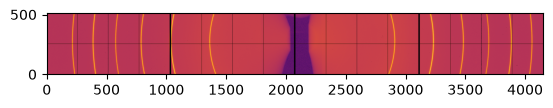

In [5]:
jupyter.display(stack[0]);

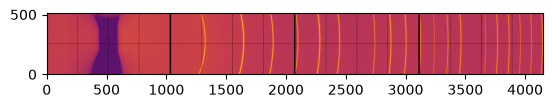

In [6]:
jupyter.display(stack[1]);

In [7]:
# Some parameters like the wavelength, the calibrant and the diffraction image:

wavelength = 0.35413267e-10
detector = pyFAI.detector_factory("eiger2_cdte_2m-w")
detector.mask = msk
calibrant = pyFAI.calibrant.CALIBRANT_FACTORY("LaB6")
calibrant.wavelength = wavelength
img = stack[0]

Uncomment the two next cells for a manual calibration of the first frame

In [8]:
# %matplotlib widget
# calib0 = Calibration(img, calibrant=calibrant, wavelength=wavelength, detector=detector)

In [9]:
# %matplotlib inline

In [10]:
# Few control points manually picked (see commented out cells #7)
data0 = [[2.16946196e+02, 1.36495621e+03, 0.00000000e+00],
       [4.98948876e+02, 1.39599020e+03, 0.00000000e+00],
       [1.33985296e+02, 1.37580774e+03, 0.00000000e+00],
       [1.56961272e+02, 1.37212619e+03, 0.00000000e+00],
       [2.06130302e+00, 1.41320516e+03, 0.00000000e+00],
       [1.93958229e+02, 1.36719401e+03, 0.00000000e+00],
       [5.19437953e+01, 1.39644646e+03, 0.00000000e+00],
       [2.34906050e+02, 1.36309143e+03, 0.00000000e+00],
       [1.65042328e+02, 1.37083362e+03, 0.00000000e+00],
       [3.88954898e+02, 2.90280016e+03, 0.00000000e+00],
       [1.58978189e+02, 2.90119235e+03, 0.00000000e+00],
       [2.74014587e+02, 2.91017822e+03, 0.00000000e+00],
       [3.67925601e+02, 2.90473544e+03, 0.00000000e+00],
       [1.92941849e+02, 2.90578101e+03, 0.00000000e+00],
       [1.64969229e+02, 2.90270789e+03, 0.00000000e+00],
       [9.90018845e+01, 1.05369397e+03, 1.00000000e+00],
       [4.44033391e+02, 1.05163881e+03, 1.00000000e+00],
       [1.23955538e+02, 1.04901727e+03, 1.00000000e+00],
       [9.58295565e-01, 1.07477978e+03, 1.00000000e+00],
       [4.13968597e+02, 1.04778491e+03, 1.00000000e+00],
       [7.19943619e+01, 1.05821899e+03, 1.00000000e+00],
       [4.39715964e+01, 1.06440885e+03, 1.00000000e+00],
       [1.83001185e+02, 1.04332263e+03, 1.00000000e+00],
       [1.30993866e+02, 3.22387598e+03, 1.00000000e+00],
       [9.37954748e+01, 3.47184852e+03, 2.00000000e+00],
       [2.89941017e+02, 3.48314557e+03, 2.00000000e+00],
       [3.81939222e+02, 3.47913308e+03, 2.00000000e+00],
       [3.50956230e+02, 3.48117090e+03, 2.00000000e+00],
       [8.19801025e+01, 3.46977222e+03, 2.00000000e+00],
       [4.88998037e+02, 3.46719716e+03, 2.00000000e+00],
       [3.00047818e+01, 3.46169776e+03, 2.00000000e+00],
       [3.61000580e+02, 3.48114746e+03, 2.00000000e+00],
       [1.70020844e+02, 3.47973267e+03, 2.00000000e+00],
       [5.07975952e+02, 8.08918579e+02, 2.00000000e+00],
       [1.59013458e+02, 7.93875427e+02, 2.00000000e+00]]

In [11]:
calib0 = AbstractCalibration(img, calibrant=calibrant, wavelength=wavelength, detector=detector)
calib0.gui = False
calib0.interactive = False
calib0.preprocess()
calib0.ai = pyFAI.load({"detector":detector, "wavelength": wavelength})
calib0.data = data0
calib0.max_iter = 10

In [12]:
calib0.refine(fixed=["rot3", "wavelength", "rot1", "rot2"])

Before refinement, the geometry is:
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 1.000000e+00 m	PONI= 0.000000e+00, 0.000000e+00 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 1000.000 mm	Center: x=0.000, y=0.000 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792935e-01 m	PONI= 2.076350e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.293 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792935e-01 m	PONI= 2.076350e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSiz

ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour


Before refinement, the geometry is:
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792936e-01 m	PONI= 2.076349e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.793034e-01 m	PONI= 2.075632e-02, 1.602593e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.303 mm	Center: x=2136.790, y=276.751 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.793034e-01 m	PONI= 2.075632e-02, 1.602593e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.303 mm	Center: x=2136.790, y=276.751 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


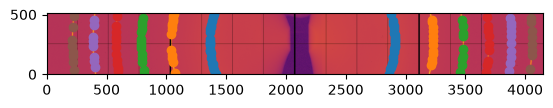

In [13]:
calib0.extract_cpt(pts_per_deg=0.5)
calib0.refine(fixed=["rot3", "wavelength", "rot1", "rot2"])
jupyter.display(img=calib0.img, cp=calib0.peakPicker.points).legend().remove();

Uncomment the two next cells for a manual calibration of the second frame

In [14]:
# %matplotlib widget
# calib1 = Calibration(stack[1], calibrant=calibrant, wavelength=wavelength, detector=detector)

In [15]:
# %matplotlib inline

In [16]:
# Uncomment previous cell to perform a manual calibration ...

data1 = [[2.10937576e+02, 1.32242532e+03, 0.00000000e+00],
       [1.19984286e+02, 1.30892846e+03, 0.00000000e+00],
       [4.18939945e+02, 1.31131973e+03, 0.00000000e+00],
       [3.80048807e+02, 1.31824455e+03, 0.00000000e+00],
       [4.96955423e+02, 1.29236931e+03, 0.00000000e+00],
       [4.55998001e+02, 1.30393703e+03, 0.00000000e+00],
       [4.67956588e+02, 1.30136134e+03, 0.00000000e+00],
       [1.56944783e+02, 1.64069626e+03, 1.00000000e+00],
       [2.48968491e+02, 1.64627808e+03, 1.00000000e+00],
       [3.54965225e+02, 1.64354648e+03, 1.00000000e+00],
       [5.03004795e+02, 1.62337791e+03, 1.00000000e+00],
       [3.99949312e+01, 1.62053608e+03, 1.00000000e+00],
       [5.99293251e+01, 1.62508024e+03, 1.00000000e+00],
       [2.19849625e+01, 1.61682495e+03, 1.00000000e+00],
       [1.91057755e+02, 1.89019165e+03, 2.00000000e+00],
       [4.41912514e+02, 1.88242116e+03, 2.00000000e+00],
       [4.01938181e+02, 1.88793859e+03, 2.00000000e+00],
       [1.20966652e+02, 1.88342356e+03, 2.00000000e+00],
       [1.37983368e+02, 1.88583423e+03, 2.00000000e+00],
       [4.65869058e+02, 1.87921598e+03, 2.00000000e+00],
       [2.11963882e+02, 2.09964038e+03, 3.00000000e+00],
       [4.55037476e+02, 2.09079077e+03, 3.00000000e+00],
       [2.60203833e+01, 2.08107749e+03, 3.00000000e+00],
       [3.00431881e+01, 2.08134253e+03, 3.00000000e+00],
       [3.16991794e+02, 2.10070978e+03, 3.00000000e+00],
       [3.27973224e+02, 2.10027699e+03, 3.00000000e+00]]

In [17]:
calib1 = AbstractCalibration(stack[1], calibrant=calibrant, wavelength=wavelength, detector=detector)
calib1.max_iter = 10
calib1.gui = False
calib1.interactive = False
calib1.preprocess()
calib1.ai = pyFAI.load({"detector":detector, "wavelength": wavelength})
calib1.data = data1
calib1.refine(fixed=["rot3", "wavelength"])   

Before refinement, the geometry is:
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 1.000000e+00 m	PONI= 0.000000e+00, 0.000000e+00 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 1000.000 mm	Center: x=0.000, y=0.000 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792103e-01 m	PONI= 6.621322e-02, 1.506045e-01 m	rot1=0.160667  rot2=-0.066212  rot3=0.000000 rad
DirectBeamDist= 689.583 mm	Center: x=540.386, y=274.509 pix	Tilt= 9.950° tiltPlanRotation= -157.487° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.791381e-01 m	PONI= 6.620319e-02, 1.505989e-01 m	rot1=0.160661  rot2=-0.066206  rot3=0.000000 rad
DirectBeamDist= 689.509 mm	Center: x=540.524, y=274.492 pix	Tilt= 9.950° tiltPlanRotation= -157.488° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 Pi

ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image available => not showing the contour
ERROR:pyFAI.gui.peak_picker:No diffraction image avail

Before refinement, the geometry is:
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.791381e-01 m	PONI= 6.620319e-02, 1.505989e-01 m	rot1=0.160661  rot2=-0.066206  rot3=0.000000 rad
DirectBeamDist= 689.509 mm	Center: x=540.524, y=274.492 pix	Tilt= 9.950° tiltPlanRotation= -157.488° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792697e-01 m	PONI= 2.478324e-02, 1.620708e-01 m	rot1=0.177205  rot2=-0.005772  rot3=0.000000 rad
DirectBeamDist= 690.088 mm	Center: x=538.996, y=277.334 pix	Tilt= 10.158° tiltPlanRotation= -178.125° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792694e-01 m	PONI= 2.478327e-02, 1.620707e-01 m	rot1=0.177205  rot2=-0.005772  rot3=0.000000 rad
DirectBeamDist= 690.087 mm	Center: x=538.996, y=277.334 pix	Tilt= 10.158° tiltPlanRotation= -178.125° λ= 0.354Å
Detector Eiger2 CdTe

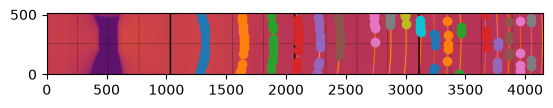

In [18]:
calib1.extract_cpt(pts_per_deg=0.5)
calib1.refine(fixed=["rot3", "wavelength"])
jupyter.display(img=calib1.img, cp=calib1.peakPicker.points).legend().remove();

In [19]:
print(calib0.geoRef)
print(calib1.geoRef)

Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.793034e-01 m	PONI= 2.075632e-02, 1.602593e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.303 mm	Center: x=2136.790, y=276.751 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792694e-01 m	PONI= 2.478327e-02, 1.620707e-01 m	rot1=0.177205  rot2=-0.005772  rot3=0.000000 rad
DirectBeamDist= 690.087 mm	Center: x=538.996, y=277.334 pix	Tilt= 10.158° tiltPlanRotation= -178.125° λ= 0.354Å


## Definition of the goniometer

* The detector is mounted vertically which means the $rot_3=\pi/2$
* Wavelength is refined (in Angstrom) close to $35keV \leftrightarrow 0.354\mathring{\text{A}}$
* Excetricity is refined, i.e. the goniometer not being centered on the sample position
* Goniometer offset is refined but it is supposed to be exact on its displacements
* The misalignment between the detector's axis 1 and the goniometer's axis is accounted for ($rot_2 \propto 1/cos(2\theta)$)

In [20]:
#Definition of the goniometer translation function:

goniotrans = ExtendedTransformation(param_names = ["D", "e", "omega", "P1", "P2", "tth_offset", "rot2", "wlA"],
                                    pos_names = ["tth"],
                                    dist_expr="D-e*cos(tth-tth_offset-omega)",
                                    poni1_expr="P1-e*sin(tth-tth_offset-omega)",
                                    poni2_expr="P2",
                                    rot1_expr="tth-tth_offset",
                                    rot2_expr="rot2/cos(tth-tth_offset)",
                                    rot3_expr="pi/2",
                                    wavelength_expr="wlA*1e-10")

In [21]:
def get_angle(idx):
    """get goniometer position in radians, not in degrees"""
    return pi*float(pos[int(idx)])/180
get_angle(5), pos#, pos_res

(0.8725762459515067,
 array([-6.24251171e-03,  9.99482422e+00,  1.99949905e+01,  2.99948640e+01,
         3.99948465e+01,  4.99949362e+01,  5.99948874e+01,  6.99947590e+01,
         7.99947702e+01]))

In [22]:
# Starting parameters and bounds
param = {"D":0.7, 
         "e":0.001, 
         "omega": 0, 
         "P1": 2.4e-2, 
         "P2": 0.16, 
         "tth_offset": 0,
         "rot2": 0.0,
         "wlA": wavelength*1e+10
         }
bounds = {"D": (0.6, 0.8),
          "e": (-0.1, 0.1),
          "omega": (-pi/2, pi/2),
          "P1": (-0.00, 0.10),
          "P2": (0.15, 0.17),
          "tth_offset": (-0.0, 0.0),
          "rot2": (-0.1, 0.1),
          "wlA": (0.30, 0.40)
         }

In [23]:
gonioref = GoniometerRefinement(param, #initial guess
                                bounds=bounds,
                                pos_function=get_angle,
                                trans_function=goniotrans,
                                detector=detector)
print("Empty refinement object:")
print(gonioref)
gonioref.new_geometry("0", image=stack[0], metadata="0", control_points=calib0.peakPicker.points,
                      geometry=calib0.geoRef, calibrant=calibrant)
gonioref.new_geometry("1", image=stack[1], metadata="1", control_points=calib1.peakPicker.points,
                      geometry=calib1.geoRef, calibrant=calibrant)
print(gonioref)

Empty refinement object:
GoniometerRefinement with 0 geometries labeled: .
GoniometerRefinement with 2 geometries labeled: 0, 1.


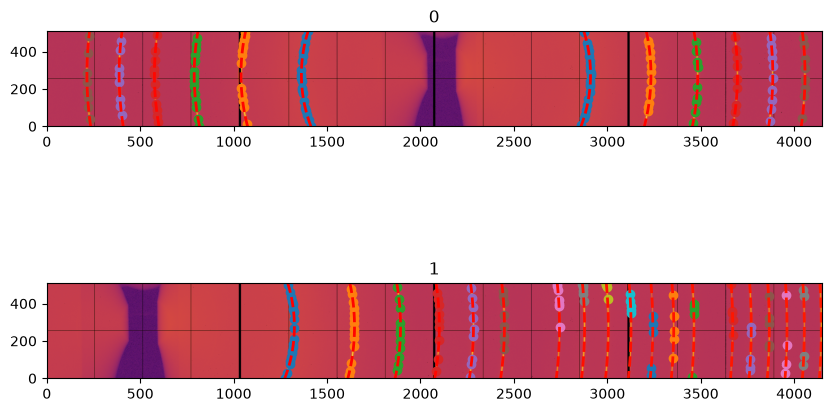

In [24]:
#Display all images with associated calibration:
nimg = len(gonioref.single_geometries)
fig,ax = subplots(nimg, 1, figsize=(10,nimg*3))
for i, sg in enumerate(gonioref.single_geometries.values()):
    jupyter.display(sg=sg, ax=ax[i]).get_legend().remove()

In [25]:
# Initial refinement of the goniometer model with 7 dof
gonioref.refine3()

Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'rot2', 'wlA']
Fixed: {'tth_offset': 0}
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1.8783637728582037e-09
           x: [ 6.788e-01 -5.246e-04  1.033e-05  2.111e-02  1.602e-01
               -5.384e-04  3.541e-01]
         nit: 26
         jac: [-9.295e-09 -9.254e-09  2.218e-10  4.093e-08  2.293e-07
                5.061e-08  9.734e-08]
        nfev: 209
        njev: 26
 multipliers: []
Constrained Least square 1.2520607646325623e-05 --> 1.8783637728582037e-09
maxdelta on D: 0.7 --> 0.6787622799175641 


np.float64(1.8783637728582037e-09)

## Refine goniometer parameter with more images

In [26]:
# This function adds new images to the pool of data used for the refinement.
# A set of new control points are extractred and a refinement step is performed at each iteration
# The last image of the serie is displayed

def optimize_with_new_images(list_images, pts_per_deg=0.5):
    sg = None
    for fname in list_images:
        print()
        base = str(fname)
        if base not in gonioref.single_geometries:
            print("Working on image #",base)
            sg = gonioref.new_geometry(base, image=stack[fname], metadata=base,
                                       calibrant=calibrant)
            print(sg.extract_cp(pts_per_deg=pts_per_deg))
        gonioref.refine3()
        print("*"*50)
    if sg:
        sg.geometry_refinement.set_param(gonioref.get_ai(sg.get_position()).param)
        jupyter.display(sg=sg).get_legend().remove()


Working on image # 2
ControlPoints instance containing 35 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.541114558271005e-11
Containing 35 groups of points:
# s ring 1: 13 points
# t ring 2: 11 points
# u ring 3: 10 points
# v ring 4: 9 points
# w ring 5: 8 points
# x ring 6: 7 points
# y ring 7: 6 points
# z ring 8: 7 points
#aa ring 9: 6 points
#ab ring 10: 6 points
#ac ring 11: 6 points
#ad ring 12: 6 points
#ae ring 14: 5 points
#af ring 15: 5 points
#ag ring 16: 5 points
#ah ring 17: 5 points
#ai ring 18: 4 points
#aj ring 19: 4 points
#ak ring 20: 4 points
#al ring 21: 4 points
#am ring 22: 4 points
#an ring 23: 4 points
#ao ring 24: 4 points
#ap ring 25: 4 points
#aq ring 26: 4 points
#ar ring 27: 3 points
#as ring 28: 4 points
#at ring 29: 4 points
#au ring 30: 4 points
#av ring 31: 2 points
#aw ring 32: 3 points
#ax ring 33: 2 points
#ay ring 34: 2 points
#az ring 35: 3 points
#ba ring 36: 3 points
Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'rot2', 

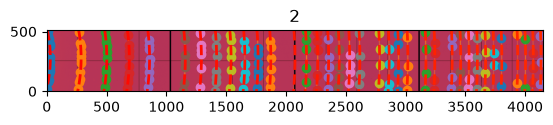

In [27]:
optimize_with_new_images([2])


Working on image # 3
ControlPoints instance containing 50 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.540792030801924e-11
Containing 50 groups of points:
#bb ring 10: 6 points
#bc ring 11: 6 points
#bd ring 12: 5 points
#be ring 13: 5 points
#bf ring 14: 5 points
#bg ring 15: 3 points
#bh ring 16: 4 points
#bi ring 17: 5 points
#bj ring 18: 5 points
#bk ring 19: 2 points
#bl ring 20: 4 points
#bm ring 21: 4 points
#bn ring 22: 4 points
#bo ring 23: 4 points
#bp ring 24: 4 points
#bq ring 25: 4 points
#br ring 26: 4 points
#bs ring 27: 4 points
#bt ring 28: 4 points
#bu ring 29: 4 points
#bv ring 31: 4 points
#bw ring 32: 3 points
#bx ring 33: 3 points
#by ring 34: 3 points
#bz ring 35: 3 points
#ca ring 36: 3 points
#cb ring 37: 3 points
#cc ring 38: 3 points
#cd ring 39: 3 points
#ce ring 40: 3 points
#cf ring 41: 3 points
#cg ring 42: 3 points
#ch ring 43: 3 points
#ci ring 44: 3 points
#cj ring 45: 1 points
#ck ring 46: 3 points
#cl ring 47: 3 points
#cm rin

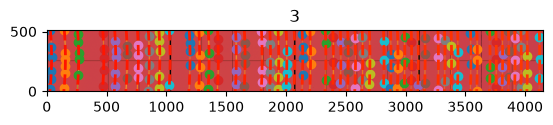

In [28]:
optimize_with_new_images([3])


Working on image # 4
ControlPoints instance containing 66 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.540469650128285e-11
Containing 66 groups of points:
#cz ring 25: 2 points
#da ring 26: 4 points
#db ring 27: 3 points
#dc ring 28: 4 points
#dd ring 29: 4 points
#de ring 30: 4 points
#df ring 31: 3 points
#dg ring 32: 3 points
#dh ring 33: 3 points
#di ring 34: 3 points
#dj ring 35: 3 points
#dk ring 36: 3 points
#dl ring 37: 3 points
#dm ring 38: 3 points
#dn ring 39: 3 points
#do ring 40: 3 points
#dp ring 41: 2 points
#dq ring 42: 3 points
#dr ring 43: 3 points
#ds ring 44: 3 points
#dt ring 45: 2 points
#du ring 46: 3 points
#dv ring 47: 3 points
#dw ring 48: 3 points
#dx ring 49: 3 points
#dy ring 50: 3 points
#dz ring 51: 3 points
#ea ring 52: 3 points
#eb ring 53: 3 points
#ec ring 54: 3 points
#ed ring 55: 3 points
#ee ring 56: 3 points
#ef ring 57: 3 points
#eg ring 58: 3 points
#eh ring 59: 3 points
#ei ring 60: 1 points
#ej ring 61: 3 points
#ek rin

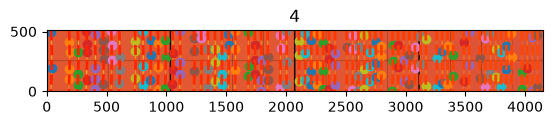

In [29]:
optimize_with_new_images([4])


Working on image # 5
ControlPoints instance containing 77 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.54028898472075e-11
Containing 77 groups of points:
#fn ring 47: 3 points
#fo ring 48: 2 points
#fp ring 49: 3 points
#fq ring 50: 3 points
#fr ring 51: 3 points
#fs ring 52: 3 points
#ft ring 53: 1 points
#fu ring 54: 3 points
#fv ring 55: 3 points
#fw ring 56: 3 points
#fx ring 57: 2 points
#fy ring 58: 1 points
#fz ring 59: 3 points
#ga ring 60: 3 points
#gb ring 61: 3 points
#gc ring 62: 3 points
#gd ring 63: 3 points
#ge ring 64: 3 points
#gf ring 65: 3 points
#gg ring 66: 3 points
#gh ring 67: 3 points
#gi ring 68: 2 points
#gj ring 69: 2 points
#gk ring 70: 2 points
#gl ring 71: 2 points
#gm ring 72: 2 points
#gn ring 73: 2 points
#go ring 74: 1 points
#gp ring 75: 2 points
#gq ring 76: 2 points
#gr ring 77: 2 points
#gs ring 78: 2 points
#gt ring 79: 2 points
#gu ring 80: 2 points
#gv ring 82: 2 points
#gw ring 83: 1 points
#gx ring 84: 2 points
#gy ring

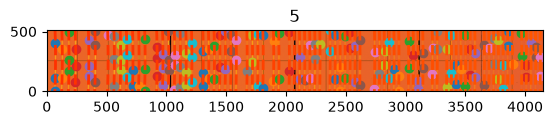

In [30]:
optimize_with_new_images([5])


Working on image # 6
ControlPoints instance containing 86 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.540154801264378e-11
Containing 86 groups of points:
#im ring 74: 2 points
#in ring 75: 1 points
#io ring 76: 2 points
#ip ring 77: 2 points
#iq ring 78: 2 points
#ir ring 79: 2 points
#is ring 80: 2 points
#it ring 81: 2 points
#iu ring 82: 1 points
#iv ring 83: 2 points
#iw ring 84: 1 points
#ix ring 85: 2 points
#iy ring 86: 2 points
#iz ring 87: 2 points
#ja ring 88: 2 points
#jb ring 89: 2 points
#jc ring 90: 1 points
#jd ring 91: 2 points
#je ring 92: 2 points
#jf ring 94: 2 points
#jg ring 95: 2 points
#jh ring 96: 2 points
#ji ring 97: 2 points
#jj ring 98: 2 points
#jk ring 99: 2 points
#jl ring 100: 2 points
#jm ring 101: 1 points
#jn ring 102: 2 points
#jo ring 103: 2 points
#jp ring 104: 2 points
#jq ring 105: 2 points
#jr ring 106: 2 points
#js ring 107: 2 points
#jt ring 108: 2 points
#ju ring 109: 2 points
#jv ring 110: 2 points
#jw ring 111: 2 po

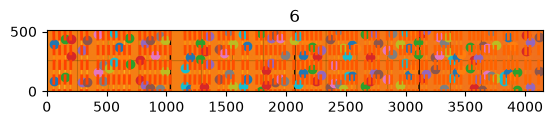

In [31]:
optimize_with_new_images([6])


Working on image # 7
ControlPoints instance containing 94 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.5400462637939056e-11
Containing 94 groups of points:
#lu ring 104: 2 points
#lv ring 105: 2 points
#lw ring 106: 2 points
#lx ring 107: 2 points
#ly ring 108: 1 points
#lz ring 109: 1 points
#ma ring 110: 2 points
#mb ring 111: 2 points
#mc ring 112: 2 points
#md ring 113: 2 points
#me ring 114: 2 points
#mf ring 115: 2 points
#mg ring 116: 2 points
#mh ring 117: 2 points
#mi ring 118: 2 points
#mj ring 119: 2 points
#mk ring 120: 2 points
#ml ring 121: 2 points
#mm ring 122: 2 points
#mn ring 123: 2 points
#mo ring 124: 2 points
#mp ring 125: 2 points
#mq ring 126: 2 points
#mr ring 127: 2 points
#ms ring 128: 2 points
#mt ring 129: 2 points
#mu ring 130: 1 points
#mv ring 131: 2 points
#mw ring 132: 2 points
#mx ring 133: 2 points
#my ring 134: 2 points
#mz ring 135: 2 points
#na ring 136: 2 points
#nb ring 137: 2 points
#nc ring 139: 2 points
#nd ring 140: 2

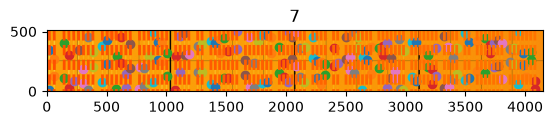

In [32]:
optimize_with_new_images([7])


Working on image # 8
ControlPoints instance containing 98 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.539979233322044e-11
Containing 98 groups of points:
#pk ring 140: 2 points
#pl ring 141: 2 points
#pm ring 142: 2 points
#pn ring 143: 2 points
#po ring 144: 2 points
#pp ring 145: 2 points
#pq ring 146: 2 points
#pr ring 147: 2 points
#ps ring 148: 2 points
#pt ring 149: 2 points
#pu ring 150: 2 points
#pv ring 151: 2 points
#pw ring 152: 2 points
#px ring 153: 2 points
#py ring 154: 2 points
#pz ring 155: 2 points
#qa ring 156: 2 points
#qb ring 157: 2 points
#qc ring 158: 2 points
#qd ring 159: 2 points
#qe ring 160: 2 points
#qf ring 161: 2 points
#qg ring 162: 2 points
#qh ring 163: 2 points
#qi ring 164: 2 points
#qj ring 165: 2 points
#qk ring 166: 2 points
#ql ring 167: 2 points
#qm ring 168: 2 points
#qn ring 169: 2 points
#qo ring 171: 2 points
#qp ring 172: 2 points
#qq ring 173: 2 points
#qr ring 174: 2 points
#qs ring 175: 2 points
#qt ring 176: 2 

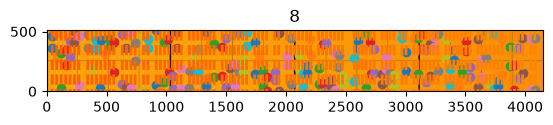

In [33]:
optimize_with_new_images([8])

In [34]:
gonioref.refine3()
gonioref.set_bounds("tth_offset", -0.1, 0.1)
gonioref.refine3()


Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'rot2', 'wlA']
Fixed: {'tth_offset': 0}
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4.753925065984775e-09
           x: [ 6.790e-01 -4.110e-04  1.042e-05  2.105e-02  1.602e-01
               -4.399e-04  3.540e-01]
         nit: 1
         jac: [-1.155e-08  1.877e-08  1.082e-10  5.359e-07 -3.286e-07
                1.895e-07  2.066e-07]
        nfev: 8
        njev: 1
 multipliers: []
Constrained Least square 4.753925065984775e-09 --> 4.753925065984775e-09
Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'tth_offset', 'rot2', 'wlA']
Fixed: {}
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4.753925065984775e-09
           x: [ 6.790e-01 -4.110e-04  1.042e-05  2.105e-02  1.602e-01
                0.000e+00 -4.399e-04  3.540e-01]
         nit: 1
         jac: [-1.155e-08  1.877e-08  1.082e-10  5.359e-07 -3.286e-07
                2.24

np.float64(4.753925065984775e-09)

In [35]:
# Refine without any constrains
gonioref.refine3(method="simplex", maxiter=1<<11)

Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'tth_offset', 'rot2', 'wlA']
Fixed: {}
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4.3241173770062275e-09
             x: [ 6.795e-01 -4.361e-04 -1.558e+00  2.054e-02  1.610e-01
                 -1.093e-03 -2.775e-04  3.540e-01]
           nit: 1870
          nfev: 2889
 final_simplex: (array([[ 6.795e-01, -4.361e-04, ..., -2.775e-04,
                         3.540e-01],
                       [ 6.795e-01, -4.361e-04, ..., -2.775e-04,
                         3.540e-01],
                       ...,
                       [ 6.795e-01, -4.361e-04, ..., -2.775e-04,
                         3.540e-01],
                       [ 6.795e-01, -4.361e-04, ..., -2.775e-04,
                         3.540e-01]], shape=(9, 8)), array([ 4.324e-09,  4.324e-09,  4.324e-09,  4.324e-09,
                        4.324e-09,  4.324e-09,  4.324e-09,  4.324e-09,
                        4.324e-09]))

np.float64(4.3241173770062275e-09)

In [36]:
#Create a MultiGeometry integrator from the refined geometry:

angles = []
images = []
for sg in gonioref.single_geometries.values():
    angles.append(sg.get_position())
    images.append(sg.image)

multigeo = gonioref.get_mg(angles)
multigeo.radial_range=(0, 90)
print(multigeo)
multigeo.empty = numpy.nan

MultiGeometry integrator with 9 geometries on (0, 90) radial range (2th_deg) and (-180, 180) azimuthal range (chi_deg)


In [37]:
# Calculate the optimal number of point for integration
over = 3
npt = int(over * numpy.deg2rad(max(multigeo.radial_range) - min(multigeo.radial_range)) /
          numpy.arctan2(detector.pixel1, gonioref.nt_param(*gonioref.param).D))
print("Number of bins: ", npt)

Number of bins:  42694


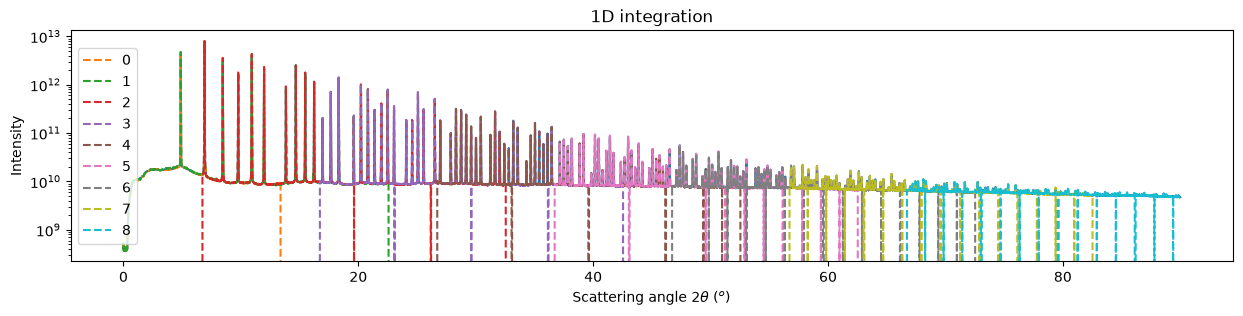

In [38]:
# Integrate the whole set of images in a single run:

res_full = multigeo.integrate1d(images, npt)
fig, ax = subplots(figsize=(15,3))
ax = jupyter.plot1d(res_full, ax=ax)
for sg in gonioref.single_geometries.values():
    ai = gonioref.get_ai(get_angle(sg.label))
    res = ai.integrate1d(sg.image, npt,
                         radial_range=multigeo.radial_range, unit=res_full.unit, 
                         normalization_factor=detector.pixel1*detector.pixel1/(ai.dist**2))
    ax.plot(res.radial, res.intensity, "--", label=sg.label)
ax.legend(loc='center left')
ax.set_yscale("log");

(np.int64(37950), np.int64(42693))


(4716091392.0, 6970806272.0)

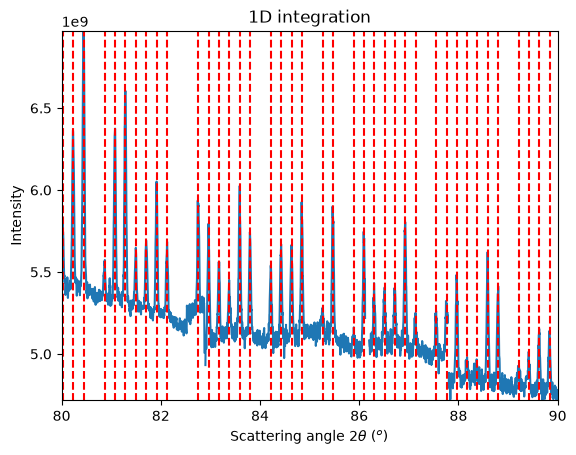

In [39]:
# Zoom on the end of the curve

range_ = 80,90
ax = jupyter.plot1d(res_full, calibrant=calibrant)
ax.set_xlim(*range_)
indices = numpy.where(res_full.radial>=range_[0])[0][0], numpy.where(res_full.radial<=range_[1])[0][-1]
print(indices)
ax.set_ylim(numpy.nanmin(res_full.intensity[indices[0]:indices[1]]),numpy.nanmax(res_full.intensity[indices[0]:indices[1]]))

In [40]:
gonioref.save("id22.json")
with open("id22.json") as f:
    print(f.read())

{
  "content": "Goniometer calibration v2",
  "detector": "Eiger2 CdTe 2M-W",
  "detector_config": {
    "pixel1": 7.5e-05,
    "pixel2": 7.5e-05,
    "orientation": 3
  },
  "wavelength": 3.539977412251697e-11,
  "param": [
    0.679506981327261,
    -0.000436063081344698,
    -1.5582076278285173,
    0.020538043944400192,
    0.16097851285995785,
    -0.0010930861119004247,
    -0.00027750918378721787,
    0.3539977412251697
  ],
  "param_names": [
    "D",
    "e",
    "omega",
    "P1",
    "P2",
    "tth_offset",
    "rot2",
    "wlA"
  ],
  "pos_names": [
    "tth"
  ],
  "trans_function": {
    "content": "ExtendedTransformation",
    "param_names": [
      "D",
      "e",
      "omega",
      "P1",
      "P2",
      "tth_offset",
      "rot2",
      "wlA"
    ],
    "pos_names": [
      "tth"
    ],
    "dist_expr": "D-e*cos(tth-tth_offset-omega)",
    "poni1_expr": "P1-e*sin(tth-tth_offset-omega)",
    "poni2_expr": "P2",
    "rot1_expr": "tth-tth_offset",
    "rot2_expr": "ro

## Evaluation of the peak-profile

209


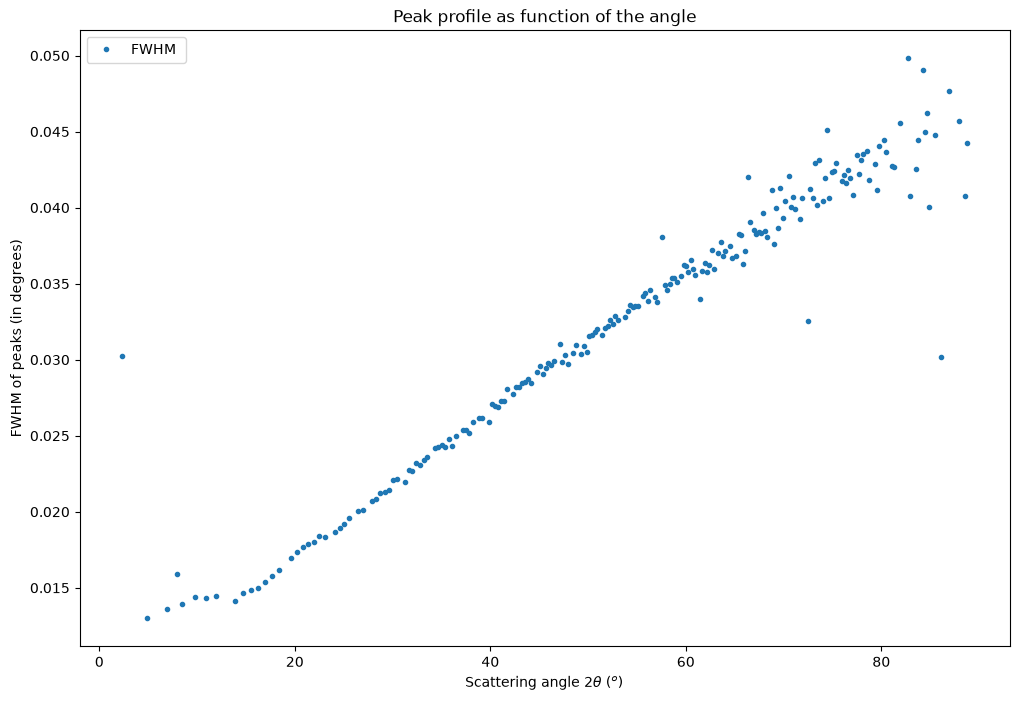

In [41]:
fig, ax = subplots(figsize=(12,8))
# ax.plot(*calc_fwhm(res_full, calibrant), "o", label="FWHM from calibrant")
ax.set_title("Peak profile as function of the angle")
ax.set_ylabel("FWHM of peaks (in degrees)")
ax.set_xlabel(res.unit.label)
resolution = (res_full.radial[1]-res_full.radial[0])
peaks = find_peaks(res_full.intensity, width=(2,25), distance=40, prominence=5e8)
ax.plot(res_full.radial[peaks[0]], resolution*peaks[1]["widths"], ".", label="FWHM ")
ax.legend(loc='upper left')
print(len(peaks[0]))
# 0.01/resolution,0.05/resolution

## re-extract all peaks to validate the peak-profile

In [42]:
def reoptimize_with_new_control_points(indices=None, pts_per_deg=0.5):
    if indices is None:
        indices = list(gonioref.single_geometries.keys())
    for label in indices:
        print()
        if label in gonioref.single_geometries:
            print("Extracting frame #", label)
            sg = gonioref.single_geometries[label]
            sg.wavelength = gonioref.param[gonioref.nt_param._fields.index("wlA")]*1e-10
            sg.extract_cp(pts_per_deg=pts_per_deg)
        else:
            continue
    print("*"*50)
    gonioref.refine3()

reoptimize_with_new_control_points(pts_per_deg = 0.7)


Extracting frame # 0

Extracting frame # 1

Extracting frame # 2

Extracting frame # 3

Extracting frame # 4

Extracting frame # 5

Extracting frame # 6

Extracting frame # 7

Extracting frame # 8
**************************************************
Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'tth_offset', 'rot2', 'wlA']
Fixed: {}
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4.5279402051776875e-09
           x: [ 6.795e-01 -4.363e-04 -1.558e+00  2.054e-02  1.610e-01
               -1.093e-03 -2.770e-04  3.540e-01]
         nit: 3
         jac: [ 2.170e-07  1.428e-07  1.227e-10 -1.022e-07  6.810e-07
                4.199e-07 -5.156e-07 -4.390e-07]
        nfev: 29
        njev: 3
 multipliers: []
Constrained Least square 4.580628018722495e-09 --> 4.5279402051776875e-09
maxdelta on wlA: 0.3539977412251697 --> 0.3539947185585394 


In [43]:
gonioref.refine3(method="simplex")

Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'tth_offset', 'rot2', 'wlA']
Fixed: {}
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4.481853228927472e-09
             x: [ 6.796e-01 -5.311e-04 -1.779e+00  2.035e-02  1.609e-01
                 -1.006e-03 -1.055e-04  3.540e-01]
           nit: 709
          nfev: 1233
 final_simplex: (array([[ 6.796e-01, -5.311e-04, ..., -1.055e-04,
                         3.540e-01],
                       [ 6.796e-01, -5.311e-04, ..., -1.055e-04,
                         3.540e-01],
                       ...,
                       [ 6.796e-01, -5.311e-04, ..., -1.055e-04,
                         3.540e-01],
                       [ 6.796e-01, -5.311e-04, ..., -1.055e-04,
                         3.540e-01]], shape=(9, 8)), array([ 4.482e-09,  4.482e-09,  4.482e-09,  4.482e-09,
                        4.482e-09,  4.482e-09,  4.482e-09,  4.482e-09,
                        4.482e-09]))
C

np.float64(4.481853228927472e-09)

In [44]:
for i,n in enumerate(gonioref.nt_param._fields):
    print(f"{n:10s} = {gonioref.param[i]}")

D          = 0.6796310375486977
e          = -0.0005310615587039839
omega      = -1.7794367941891407
P1         = 0.020352794960821964
P2         = 0.1609175107170704
tth_offset = -0.0010057614335797953
rot2       = -0.00010554997849801306
wlA        = 0.35399568868431164


In [45]:
multigeo = gonioref.get_mg(angles)
multigeo.radial_range=(0, 90)
print(multigeo)
multigeo.empty = numpy.nan
res_full = multigeo.integrate1d(images, npt)

MultiGeometry integrator with 9 geometries on (0, 90) radial range (2th_deg) and (-180, 180) azimuthal range (chi_deg)


In [46]:
res_full.intensity[:] = pyFAI.utils.mathutil.interp_filter(res_full.intensity)

In [47]:
calibrant.wavelength = gonioref.param[-1]*1e-10

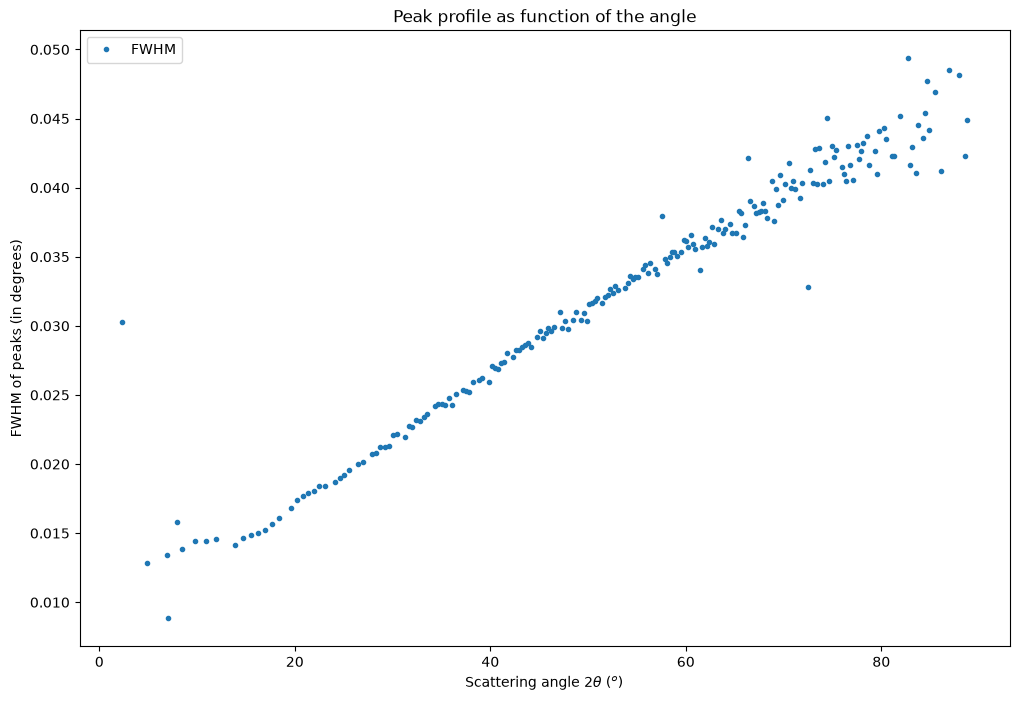

In [50]:
fig, ax = subplots(figsize=(12,8))
ax.set_title("Peak profile as function of the angle")
ax.set_ylabel("FWHM of peaks (in degrees)")
ax.set_xlabel(res.unit.label)
resolution = (res_full.radial[1]-res_full.radial[0])
peaks = find_peaks(res_full.intensity, width=(2,30), distance=40, prominence=5e8)
ax.plot(res_full.radial[peaks[0]], (res_full.radial[1]-res_full.radial[0])*peaks[1]["widths"], ".", label="FWHM")
ax.legend();

In [49]:
print(f"execution time: {time.perf_counter()-start_time:.3f}s")

execution time: 106.731s
